
# 🧠 Multiclass Semantic Segmentation on ACDC Dataset using Intel DPT-Large (TIMM + Albumentations)

This Google Colab notebook performs **multiclass semantic segmentation** on the **ACDC dataset** using the **Intel DPT-Large backbone** from `timm`.
It includes advanced data augmentation with **Albumentations**, combined **Dice + CrossEntropy loss**, and evaluation metrics such as **IoU**, **Dice Score**, and **Pixel Accuracy**.


## 🧩 Step 1: Setup and Installation

In [ ]:

!pip install timm albumentations torchmetrics matplotlib opencv-python tqdm --quiet

import os
import random
import numpy as np
import cv2
import torch
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import torch.nn.functional as F
# from torchmetrics.segmentation import MulticlassJaccardIndex, MulticlassDice, MulticlassAccuracy
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

scaler = torch.cuda.amp.GradScaler()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.5 MB/s eta 0:00:00
Using device: cuda


/tmp/ipython-input-2872396967.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rarfile
import rarfile
rar_path = '/content/drive/MyDrive/ACDC_dataset.rar'  # Change path if needed
extract_to = '/content/drive/MyDrive/acdc'  # Destination directory

with rarfile.RarFile(rar_path, 'r') as rar_ref:
    rar_ref.extractall(extract_to)

KeyboardInterrupt: 

## 📂 Step 2: Dataset Preparation

In [ ]:

DATASET_DIR = "/content/drive/MyDrive/acdc/ACDC_dataset"  # Change if needed
IMG_DIR = os.path.join(DATASET_DIR, "images")
MASK_DIR = os.path.join(DATASET_DIR, "labels")

image_files = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

assert len(image_files) == len(mask_files), "Mismatch between images and labels count!"

data_pairs = list(zip(image_files, mask_files))
random.shuffle(data_pairs)

total = len(data_pairs)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_pairs = data_pairs[:train_end]
val_pairs = data_pairs[train_end:val_end]
test_pairs = data_pairs[val_end:]

print(f"Total: {total}, Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")


Total: 5706, Train: 4564, Val: 571, Test: 571


## 🧰 Step 3: Define Albumentations Transforms and Dataset Class

In [ ]:

IMAGE_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class ACDCDataset(Dataset):
    def __init__(self, pairs, img_dir, mask_dir, transform=None):
        self.pairs = pairs
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
      img_name, mask_name = self.pairs[idx]
      img_path = os.path.join(self.img_dir, img_name)
      mask_path = os.path.join(self.mask_dir, mask_name)

      image = cv2.imread(img_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)  # Keep exact class labels

      if self.transform:
          augmented = self.transform(image=image, mask=mask)
          image = augmented['image']
          mask = augmented['mask']

      return {"pixel_values": image, "mask_labels": mask.long()}




train_dataset = ACDCDataset(train_pairs, IMG_DIR, MASK_DIR, transform=train_transform)
val_dataset = ACDCDataset(val_pairs, IMG_DIR, MASK_DIR, transform=val_transform)
test_dataset = ACDCDataset(test_pairs, IMG_DIR, MASK_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=4)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 🧠 Step 4: Model Definition — Intel DPT-Large Backbone

In [ ]:
# from transformers import DPTFeatureExtractor, DPTForSemanticSegmentation

# model_name = "Intel/dpt-large"
# processor = DPTFeatureExtractor.from_pretrained(model_name)
# model = DPTForSemanticSegmentation.from_pretrained(model_name, num_labels=4)
# model.to(device)

from transformers import DPTForSemanticSegmentation, DPTFeatureExtractor

# Define number of output classes for segmentation
NUM_CLASSES = 4  # Update this according to your dataset

# Load the DPT model configured for semantic segmentation
model = DPTForSemanticSegmentation.from_pretrained(
    "Intel/dpt-large",
    num_labels=NUM_CLASSES,  # Specify the number of classes for output
    ignore_mismatched_sizes=True  # Ignore mismatched layer sizes
).to("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available, else fallback to CPU

# Load the corresponding feature extractor
feature_extractor = DPTFeatureExtractor.from_pretrained("Intel/dpt-large")

# Verify the model and feature extractor
print(f"Model loaded: {model}")
print(f"Feature Extractor loaded: {feature_extractor}")


Some weights of DPTForSemanticSegmentation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['auxiliary_head.head.0.weight', 'auxiliary_head.head.1.bias', 'auxiliary_head.head.1.num_batches_tracked', 'auxiliary_head.head.1.running_mean', 'auxiliary_head.head.1.running_var', 'auxiliary_head.head.1.weight', 'auxiliary_head.head.4.bias', 'auxiliary_head.head.4.weight', 'head.head.1.bias', 'head.head.1.num_batches_tracked', 'head.head.1.running_mean', 'head.head.1.running_var', 'head.head.1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DPTForSemanticSegmentation were not initialized from the model check

Model loaded: DPTForSemanticSegmentation(
  (dpt): DPTModel(
    (embeddings): DPTViTEmbeddings(
      (patch_embeddings): DPTViTPatchEmbeddings(
        (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DPTViTEncoder(
      (layer): ModuleList(
        (0-23): 24 x DPTViTLayer(
          (attention): DPTViTAttention(
            (attention): DPTSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (output): DPTViTSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): DPTViTIntermediate(
            (dense): Linear(in_features=1024, out_f

In [ ]:

# class DPTSegNet(nn.Module):
#     def __init__(self, num_classes=4):
#         super().__init__()
#         self.model = timm.create_model("", pretrained=True)
#         self.decoder = nn.Sequential(
#             nn.Conv2d(768, 256, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(256, num_classes, kernel_size=1)
#         )
#     def forward(self, x):
#         feats = self.model.forward_features(x)
#         x = self.decoder(feats)
#         x = F.interpolate(x, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
#         return x

# model = DPTSegNet(num_classes=4).to(device)


## ⚙️ Step 5: Loss Function, Optimizer, Scheduler

In [ ]:
# =============================
# 1️⃣ Dice Loss & Combined Loss
# =============================
def dice_loss(pred, target, weights=None, smooth=1e-6):
    pred_softmax = F.softmax(pred, dim=1)
    num_classes = pred.shape[1]
    target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(pred_softmax * target_onehot, dims)
    cardinality = torch.sum(pred_softmax + target_onehot, dims)
    dice_per_class = (2. * intersection + smooth) / (cardinality + smooth)

    if weights is not None:
        dice_per_class = dice_per_class * weights
        dice_score_val = dice_per_class.sum() / weights.sum()
    else:
        dice_score_val = dice_per_class.mean()

    return 1 - dice_score_val

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.class_weights = class_weights

    def forward(self, outputs, targets):
        ce = self.ce_loss(outputs, targets)
        dice = dice_loss(outputs, targets, weights=self.class_weights)
        return self.ce_weight * ce + self.dice_weight * dice

# =============================
# 2️⃣ Compute Class Weights
# =============================
def compute_class_weights(dataloader, num_classes):
    print("\nComputing class weights...")
    total_pixels = torch.zeros(num_classes, dtype=torch.float32)

    for batch in tqdm(dataloader):
        masks = batch["mask_labels"]  # Shape: [B, H, W]
        if masks.ndim == 4:  # Sometimes masks may have channel dim
            masks = masks.squeeze(1)
        for c in range(num_classes):
            # Compute number of pixels in batch belonging to class c
            total_pixels[c] += (masks == c).sum().item()

    freq = total_pixels / total_pixels.sum()
    weights = 1.0 / (freq + 1e-6)
    weights = weights / weights.sum() * num_classes
    print(f"Class weights: {weights}")
    return weights

# =============================
# 3️⃣ Dice Score & Accuracy
# =============================
# def dice_score(pred, target, smooth=1e-6):
#     pred = torch.argmax(pred, dim=1)
#     pred_flat = pred.view(-1)
#     target_flat = target.view(-1)
#     intersection = (pred_flat == target_flat).float().sum()
#     return (2. * intersection + smooth) / (pred_flat.numel() + target_flat.numel() + smooth)

def dice_score(pred, target, num_classes=4, smooth=1e-6):
    """
    Computes mean Dice coefficient over all classes.
    """
    pred = torch.argmax(pred, dim=1)
    pred_onehot = F.one_hot(pred, num_classes).permute(0, 3, 1, 2).float()
    target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()

    intersection = torch.sum(pred_onehot * target_onehot, dim=(0, 2, 3))
    union = torch.sum(pred_onehot + target_onehot, dim=(0, 2, 3))
    dice_per_class = (2. * intersection + smooth) / (union + smooth)

    return dice_per_class  # tensor of length num_classes

def pixel_accuracy(pred, target):
    pred = torch.argmax(pred, dim=1)
    correct = (pred == target).float()
    return correct.sum() / correct.numel()

# =============================
# 4️⃣ Visualization of Predictions
# =============================
def visualize_predictions(model, dataloader, device, num_samples=3, class_colors=None):
    """
    Visualize model predictions and ground truth side-by-side with color coding.
    """
    model.eval()
    samples_shown = 0

    if class_colors is None:
        # Default ACDC colors (background, RV, myocardium, LV)
        class_colors = [
            (0, 0, 0),        # background - black
            (255, 0, 0),      # RV - red
            (0, 255, 0),      # myocardium - green
            (0, 0, 255)       # LV - blue
        ]

    with torch.no_grad():
        # Assuming dataloader returns (images, masks) tuple
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images).logits
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.shape[0]):
                if samples_shown >= num_samples:
                    return
                img = images[i].detach().cpu().permute(1, 2, 0).numpy()
                img = (img - img.min()) / (img.max() - img.min())  # Normalize

                gt_mask = masks[i].detach().cpu().numpy()
                pred_mask = preds[i].detach().cpu().numpy()

                def colorize_mask(mask):
                    h, w = mask.shape
                    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
                    for c, color in enumerate(class_colors):
                        color_mask[mask == c] = color
                    return color_mask

                gt_color = colorize_mask(gt_mask)
                pred_color = colorize_mask(pred_mask)

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img)
                axs[0].set_title("Input Image")
                axs[0].axis('off')

                axs[1].imshow(gt_color)
                axs[1].set_title("Ground Truth")
                axs[1].axis('off')

                axs[2].imshow(pred_color)
                axs[2].set_title("Prediction")
                axs[2].axis('off')

                plt.tight_layout()
                plt.show()

                samples_shown += 1

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
scaler = GradScaler()

/tmp/ipython-input-180999952.py:151: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 🚀 Step 6: Training Loop

In [ ]:
# =============================
# 6️⃣ Training Function
# =============================
def train_dpt_model(model, train_loader, val_loader, device, num_classes, num_epochs=30, lr=3e-5):
    class_weights = compute_class_weights(train_loader, num_classes).to(device)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    loss_fn = CombinedLoss(class_weights)
    scaler = torch.cuda.amp.GradScaler()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_dice': [], 'val_dice': []}
    best_val_loss = float('inf')
    # best_val_dice = 0
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss=train_correct=train_dice_total=total_pixels=0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs = batch["pixel_values"].to(device)
            masks = batch["mask_labels"].to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs).logits
                if outputs.shape[-2:] != masks.shape[-2:]:
                    masks = F.interpolate(masks.unsqueeze(1).float(), size=outputs.shape[-2:], mode="nearest").squeeze(1).long()
                loss = loss_fn(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            train_correct += (torch.argmax(outputs, dim=1)==masks).sum().item()
            train_dice_total += dice_score(outputs, masks).mean().item()
            total_pixels += torch.numel(masks)

        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)
        train_acc = (train_correct / total_pixels)*100
        train_dice = train_dice_total / len(train_loader)

        model.eval()
        val_loss=val_correct=val_dice_total=val_total_pixels=0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                inputs = batch["pixel_values"].to(device)
                masks = batch["mask_labels"].to(device)
                outputs = model(inputs).logits
                if outputs.shape[-2:] != masks.shape[-2:]:
                    masks = F.interpolate(masks.unsqueeze(1).float(), size=outputs.shape[-2:], mode="nearest").squeeze(1).long()
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()
                val_correct += (torch.argmax(outputs, dim=1)==masks).sum().item()
                val_dice_total += dice_score(outputs, masks).mean().item()
                val_total_pixels += torch.numel(masks)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = (val_correct / val_total_pixels)*100
        val_dice = val_dice_total / len(val_loader)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "checkpoints/best_model.pth")
            print(f"✅ Best model saved at epoch {epoch+1}, Val Loss: {best_val_loss:.4f}")

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)

        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.2f}%, Dice: {train_dice:.4f}")
        print(f"Val   Loss: {avg_val_loss:.4f}, Acc: {val_acc:.2f}%, Dice: {val_dice:.4f}")

    # Plot metrics
    epochs = range(1, num_epochs+1)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1); plt.plot(epochs,history['train_loss'],label='Train'); plt.plot(epochs,history['val_loss'],label='Val'); plt.title('Loss'); plt.legend(); plt.grid(True)
    plt.subplot(1,3,2); plt.plot(epochs,history['train_acc'],label='Train'); plt.plot(epochs,history['val_acc'],label='Val'); plt.title('Accuracy'); plt.legend(); plt.grid(True)
    plt.subplot(1,3,3); plt.plot(epochs,history['train_dice'],label='Train'); plt.plot(epochs,history['val_dice'],label='Val'); plt.title('Dice'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

    return history


Computing class weights...


  0%|          | 0/571 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 571/571 [07:49<00:00,  1.22it/s]
/tmp/ipython-input-916878441.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Class weights: tensor([0.0176, 1.3288, 1.3260, 1.3276])


Epoch 1/30 - Training:   0%|          | 0/571 [00:00<?, ?it/s]/tmp/ipython-input-916878441.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30 - Validation: 100%|██████████| 143/143 [00:57<00:00,  2.47it/s]


✅ Best model saved at epoch 1, Val Dice: 36.2916

Epoch 1/30 Summary:
Train Loss: 0.4597, Acc: 93.49%, Dice: 0.7449
Val   Loss: 0.2538, Acc: 98.54%, Dice: 0.8411


...

✅ Best model saved at epoch 28, Val Dice: 7.8403

Epoch 28/30 Summary:
Train Loss: 0.0565, Acc: 99.67%, Dice: 0.9595
Val   Loss: 0.0548, Acc: 99.70%, Dice: 0.9601


Epoch 29/30 - Validation: 100%|██████████| 143/143 [00:35<00:00,  4.02it/s]


✅ Best model saved at epoch 29, Val Dice: 7.7851

Epoch 29/30 Summary:
Train Loss: 0.0561, Acc: 99.68%, Dice: 0.9598
Val   Loss: 0.0544, Acc: 99.71%, Dice: 0.9604


Epoch 30/30 - Validation: 100%|██████████| 143/143 [00:35<00:00,  4.02it/s]


✅ Best model saved at epoch 30, Val Dice: 7.7785

Epoch 30/30 Summary:
Train Loss: 0.0559, Acc: 99.68%, Dice: 0.9601
Val   Loss: 0.0544, Acc: 99.70%, Dice: 0.9602


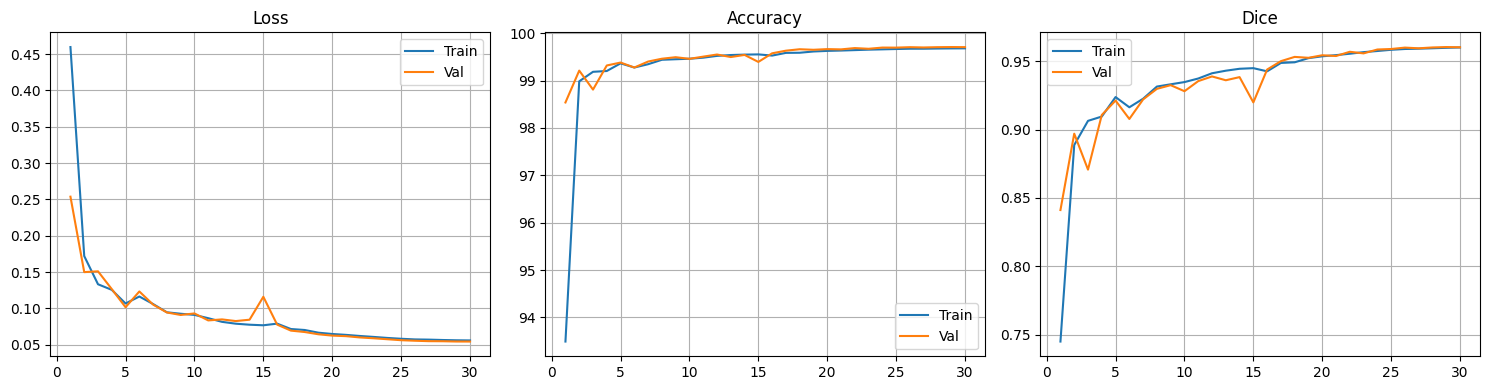

In [ ]:
# =============================
# 3️⃣ Train the model
# =============================

# device = "cuda" if torch.cuda.is_available() else "cpu"
# history = train_dpt_model(model, train_loader, val_loader, device=device, num_classes=4, num_epochs=50)
#

device = "cuda" if torch.cuda.is_available() else "cpu"
history = train_dpt_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_classes=4,
    num_epochs=30,   # you can change epochs
    lr=5e-5
)

#visualize_predictions(model, val_loader, device=device, num_samples=5)



In [ ]:
# ===================================
# 6️⃣ Testing (Class-wise Metrics)
# ===================================
def evaluate_model(model, loader, device, num_classes=4, class_names=None):
    model.eval()
    tot_dice = torch.zeros(num_classes, device=device)
    count = 0
    with torch.no_grad():
        for b in tqdm(loader, desc="Testing"):
            x, y = b["pixel_values"].to(device), b["mask_labels"].to(device)
            out = model(x).logits
            dice = dice_score(out, y, num_classes)
            tot_dice += dice
            count += 1
    avg_dice = (tot_dice / count).cpu().numpy()
    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
    print("\n===== CLASS-WISE DICE SCORES =====")
    for i, n in enumerate(class_names):
        print(f"{n}: {avg_dice[i]:.4f}")
    print(f"Mean Dice: {avg_dice.mean():.4f}")
    return avg_dice




# --- Visualization and Testing ---

class_names = ["Background", "RV", "Myocardium", "LV"]
evaluate_model(model, test_loader, device, num_classes=4, class_names=class_names)

Testing:   0%|          | 0/143 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 143/143 [01:06<00:00,  2.16it/s]


===== CLASS-WISE DICE SCORES =====
Background: 0.9988
RV: 0.9312
Myocardium: 0.9229
LV: 0.9752
Mean Dice: 0.9570


array([0.9987701 , 0.9311947 , 0.9228613 , 0.97521746], dtype=float32)

In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=3, class_colors=None):
    model.eval()
    if class_colors is None:
        class_colors = [(0, 0, 0), (255, 0, 0), (0, 255, 0), (0, 0, 255)]  # 4 classes

    shown = 0
    with torch.no_grad():
        for batch in dataloader:
            images = batch["pixel_values"].to(device)
            masks = batch["mask_labels"]
            outputs = model(images).logits
            preds = torch.argmax(outputs, dim=1).cpu()

            for i in range(images.size(0)):
                if shown >= num_samples:
                    return

                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img - img.min()) / (img.max() - img.min())
                gt = masks[i].numpy()
                pr = preds[i].numpy()

                def colorize(mask):
                    color_img = np.zeros((*mask.shape, 3), dtype=np.uint8)
                    for cls, color in enumerate(class_colors):
                        color_img[mask == cls] = color
                    return color_img

                plt.figure(figsize=(10, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(img)
                plt.title("Input")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(colorize(gt))
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(colorize(pr))
                plt.title("Prediction")
                plt.axis("off")

                plt.show()
                shown += 1


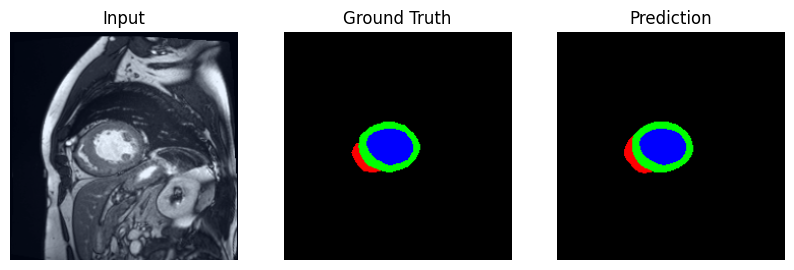

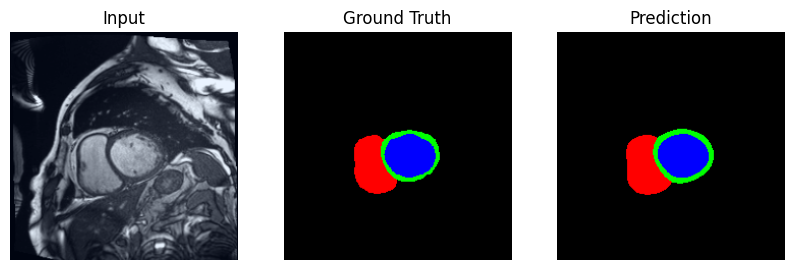

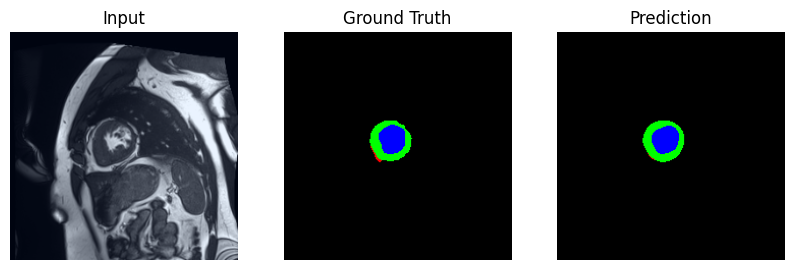

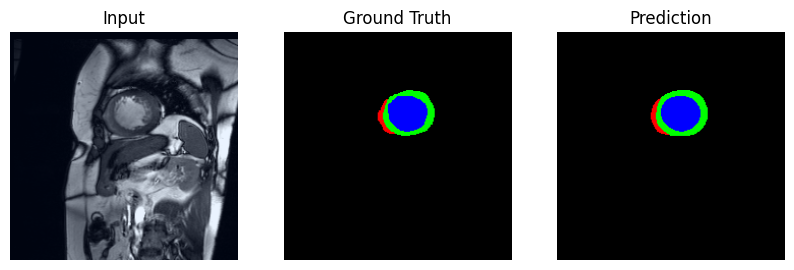

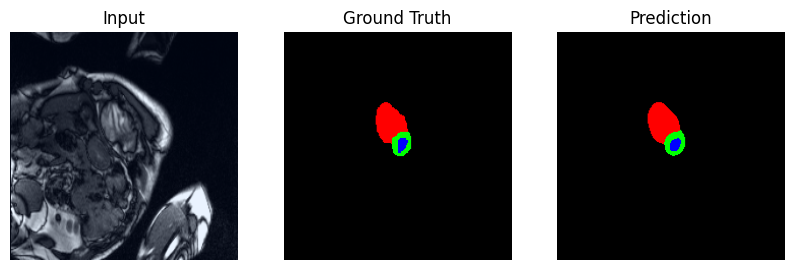

In [ ]:
visualize_predictions(model, test_loader, device=device, num_samples=5)


In [ ]:
torch.save({
        # 'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # 'val_dice': val_dice,
        # 'val_loss': avg_val_loss
    }, best_model_path)

In [ ]:
save_dir = "/content/drive/MyDrive/DPT_Models"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model_dpt_large.pth")

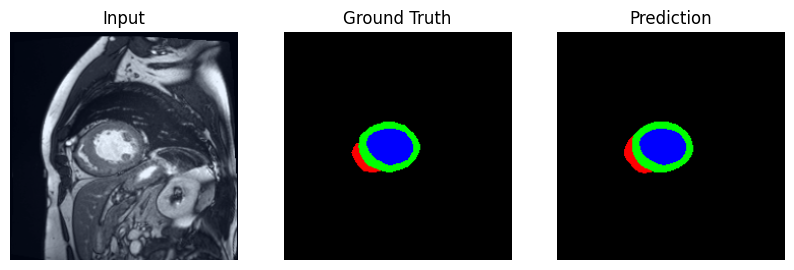

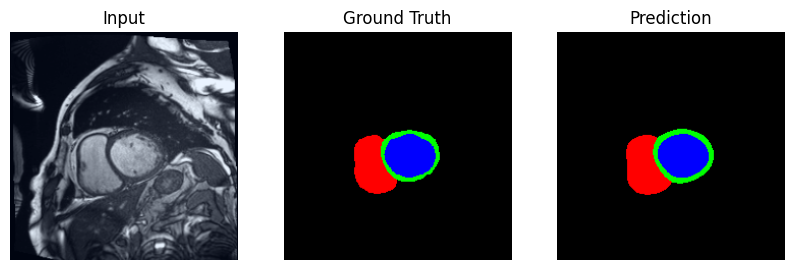

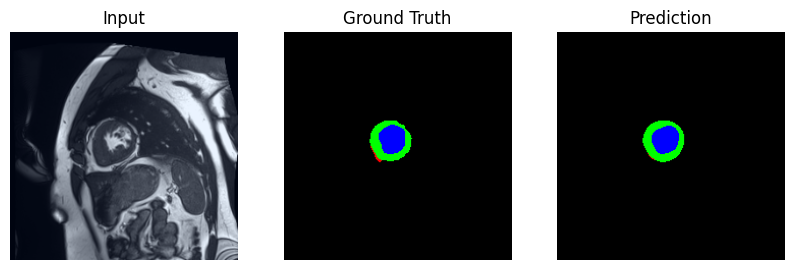

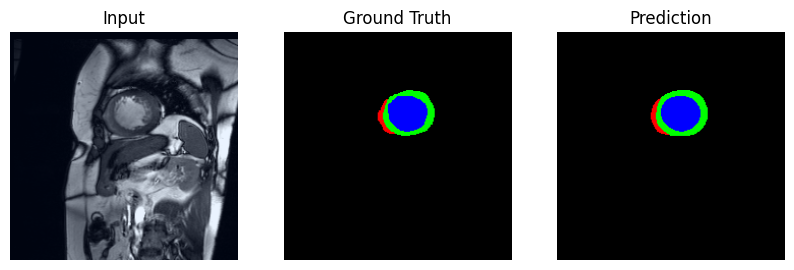

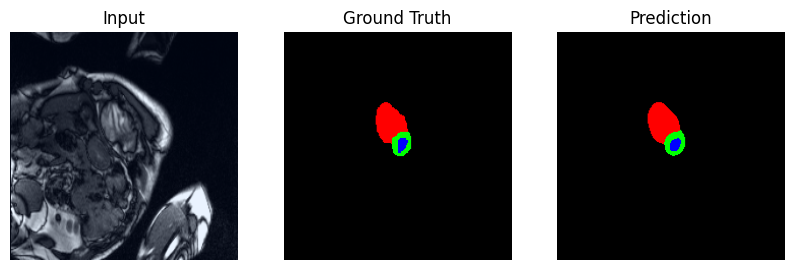

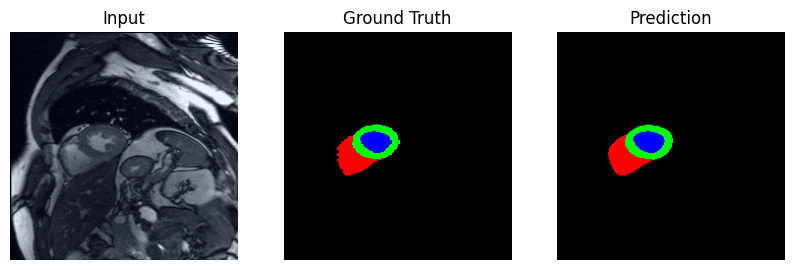

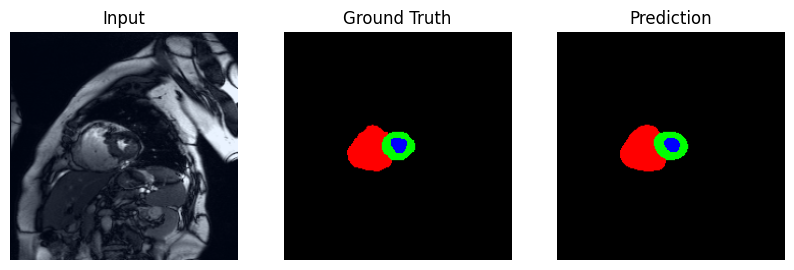

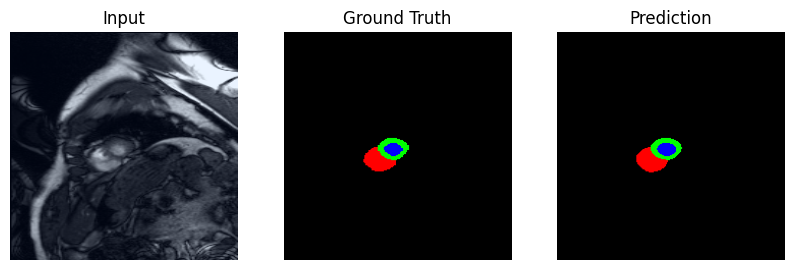

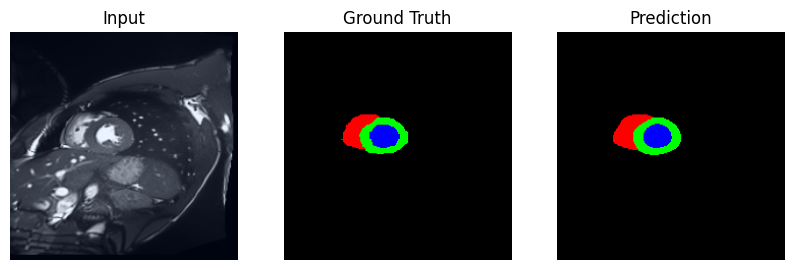

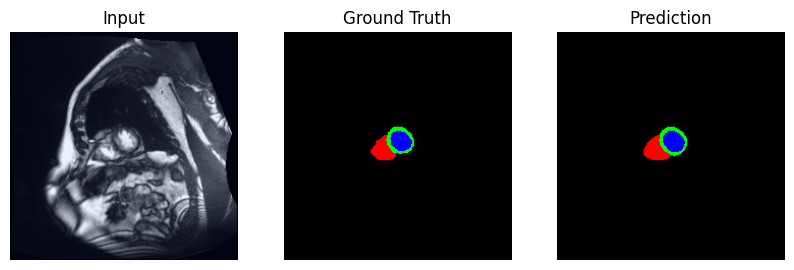

In [ ]:
visualize_predictions(model, test_loader, device, num_samples=10)

END OF the CODE